# Mosaic integration


`NetworkVI` is a Variational Autoencoder for the paired and mosaic integration of multimodal single-cell data. Each single-cell modality is learned in individual encoders; the latent spaces are then aligned for a joint representation. In this notebook we demonstrate how to use `NetworkVI` for mosaic integration. We use two publically available CITE-seq and Multiome datasets created by {cite}`Luecken2021`.

If you use `NetworkVI`, please consider citing:

Arnoldt, L., Upmeier zu Belzen, J., Herrmann, L., Nguyen, K., Theis, F.J., Wild, B. , Eils, R., "Biologically Guided Variational Inference for Interpretable Multimodal Single-Cell Integration and Mechanistic Discovery", bioRxiv, June 2025.

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install networkvi

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import requests
import sys
sys.path.append("../../src")
import networkvi
from networkvi.model import NETWORKVI
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import sklearn
from sklearn.preprocessing import normalize
import seaborn as sns
import pandas as pd

In [4]:
%matplotlib inline

In [5]:
os.makedirs("../../resources/", exist_ok=True)

In [6]:
if not os.path.isfile(os.path.join("../../resources/", "go-basic.obo")):
    r = requests.get("http://purl.obolibrary.org/obo/go/go-basic.obo", allow_redirects=True)
    open(os.path.join("../../resources/", "go-basic.obo"), 'wb').write(r.content)

In [7]:
gene_csv_path = "../../gene_interactions.csv"
gene_csv_url = "https://zenodo.org/records/19376389/files/ENCFF173VDJ_K562_GRCh38_contact_domains_juicertools.csv?download=1"

if not os.path.isfile(gene_csv_path):
    print(f"Downloading {gene_csv_path} from Zenodo...")
    r = requests.get(gene_csv_url)
    r.raise_for_status()
    with open(gene_csv_path, "wb") as f:
        f.write(r.content)
    print("Download complete.")

## Data loading

We provide a subsetted and preprocessed version of the CITE-seq and Multiome dataset for this tutorial. We filtered low quality cells, lowly expressed features and performed subsampling to 5000 cells and feature subselection to 4000 highly variable genes and 20000 highly variable ATAC peaks. `NetworkVI` accepts raw counts data for all modalities. For details on the preprocessing please refer to the manuscript and the code in the [NetworkVI reproducibility repository](https://github.com/LArnoldt/networkvi_reproducibility). In the repository we also provide scripts for downloading and processing the datasets used in the manuscript. The original CITE-seq dataset contains 90261 bone marrow mononuclear cells inferred at 4 different sites with 13953 genes and 143 proteins. The original Multiome dataset contains 69249 cells with 13,431 genes and 116,490 peaks.

In [8]:
rna_cite_path = "neurips2021_cite_bmmc_luecken2021.h5ad"
rna_cite_url = "https://zenodo.org/records/19376389/files/neurips2021_cite_bmmc_luecken2021.h5ad?download=1"

if not os.path.isfile(rna_cite_path):
    print(f"Downloading {rna_cite_path} from Zenodo...")
    r = requests.get(rna_cite_url)
    r.raise_for_status()
    with open(rna_cite_path, "wb") as f:
        f.write(r.content)
    print("Download complete.")

rna_cite = sc.read_h5ad(rna_cite_path)

AnnData object with n_obs × n_vars = 5000 × 4000
    obs: 'cell_type', 'Site', 'DonorID', 'DonorSmoker', 'DonorBMI', 'DonorAge'
    var: 'gene_stable_id', 'modality'
    uns: 'protein_expression'
    obsm: 'protein_expression'

In [9]:
rna_multiome_path = "neurips2021_multiome_bmmc_luecken2021.h5ad"
rna_multiome_url = "https://zenodo.org/records/19376389/files/neurips2021_multiome_bmmc_luecken2021.h5ad?download=1"

if not os.path.isfile(rna_multiome_path):
    print(f"Downloading {rna_multiome_path} from Zenodo...")
    r = requests.get(rna_multiome_url)
    r.raise_for_status()
    with open(rna_multiome_path, "wb") as f:
        f.write(r.content)
    print("Download complete.")

rna_multiome = sc.read_h5ad(rna_multiome_path)

AnnData object with n_obs × n_vars = 5000 × 24001
    obs: 'cell_type', 'Site', 'DonorID'
    var: 'gene_stable_id', 'modality'

## Data setup

`NetworkVI` is trained on all modalities that are not null for a sample for all features. This means that missing modalities, e.g. for a mosaic integration, must be represented using empty arrays. Here we combine the CITE-seq and Multiome dataset. In the manuscript we demonstrate mosaic integration by artificially removing subsets of each benchmarked dataset.

In [10]:
adata = sc.concat([rna_cite, rna_multiome], join="outer", merge="first")
adata.obsm["protein_expression"] = np.nan_to_num(adata.obsm["protein_expression"], nan=0)
adata.obs["modality"] = ["CITE"] * 5000 + ["Multiome"] * 5000

gene_stable_ids = []
for gene_name in adata.var.index:
    try:
        gene_stable_ids.append(rna_cite.var.loc[gene_name, "gene_stable_id"])
    except KeyError:
        gene_stable_ids.append(rna_multiome.var.loc[gene_name, "gene_stable_id"])
adata.var["gene_stable_id"] = gene_stable_ids
adata.var["modality"] = ["Peaks" if gene_name.startswith("chr") else "Gene Expression" for gene_name in adata.var.index]

We register the fields and setup the anndata with a convenience function as shown below. `NetworkVI` requires as `MultiVI` to register the modality as the `batch_key`. Further batch information can be registered as `categorical_covariate_keys`.

In [11]:
NETWORKVI.setup_anndata(
    adata,
    batch_key="modality",
    categorical_covariate_keys=["Site"],
    protein_expression_obsm_key="protein_expression",
)

## Model setup and training

We demonstrate the setup and training of `NetworkVI`, which makes use of the Gene Ontology, as the encoder structure. Below we define a convenience function to get the latent representation and to visualize the latent space. `NetworkVI` requires as `MultiVI` the definition of the number of features per modality (`n_genes`, `n_proteins`, `n_regions`).

In [12]:
def get_plot_latent_representation(vae, adata):
    latent_representation = vae.get_latent_representation(modality="joint")
    adata.obsm["X_NetworkVI"] = latent_representation
    sc.pp.neighbors(adata, use_rep="X_NetworkVI")
    sc.tl.umap(adata, n_components=2)
    return adata

### NetworkVI

The mapping of the features to the gene layer and the Gene Ontology requires ENSEMBL-IDs, which we provide in `ensembl_ids_genes` and `ensembl_ids_proteins`. We also provide the Gene Ontology and a gene-to-GO mapping file in `obo_file` and `map_ensembl_go`. Please don't use the provided mapping file in production since it's an artifically subsampled version of a real mapping file. Please refer to the scripts provided [here](https://github.com/Larnoldt/networkvi_reproducibility) or [here](https://geneontology.org/docs/go-annotation-file-gaf-format-2.1/) to download full mapping files.

In [13]:
vae =NETWORKVI(
    adata,
    n_genes=len(adata.var[adata.var["modality"] == "Gene Expression"]),
    n_regions=len(adata.var[adata.var["modality"] == "Peaks"]),
    n_proteins=adata.obsm["protein_expression"].shape[1],
    ensembl_ids_genes=np.array(adata.var[adata.var["modality"] == "Gene Expression"]["gene_stable_id"]),
    ensembl_ids_regions=np.array(adata.var[adata.var["modality"] == "Peaks"]["gene_stable_id"]),
    ensembl_ids_proteins=np.array(rna_cite.uns["protein_expression"]["var"]["gene_stable_id"]),
    gene_layer_interaction_source="../../gene_interactions.csv",
    expression_gene_layer_type="interaction",
    protein_gene_layer_type="interaction",
    obo_file="../../resources/go-basic.obo",
    map_ensembl_go=["../../resources/ensembl2go.gaf"],
    layers_encoder_type="go",
    encode_covariates=True,
    deeply_inject_covariates=True,
    standard_gene_size=5,
    standard_go_size=2,
)

vae.train(max_epochs=10, adversarial_mixing=True, save_best=False)

Generated block structure with len 6493 (0.00015401201293700908 blocks).


Generated block structure with len 13917 (0.0003301070666940329 blocks).


../../resources/go-basic.obo: fmt(1.2) rel(2025-03-16) 43,544 Terms; optional_attrs(relationship)


../../resources/go-basic.obo: fmt(1.2) rel(2025-03-16) 43,544 Terms; optional_attrs(relationship)


_biological_process_go-basic_ensembl2go.v2_processed.pkl
Using attention in GO model at level -1.


...

Epoch 10/10:  90%|█████████████████████████████████████████████████▌     | 9/10 [16:55<01:42, 102.72s/it, v_num=1, train_loss_step=5.08e+3, train_loss_epoch=4.75e+3]

Epoch 10/10: 100%|██████████████████████████████████████████████████████| 10/10 [18:36<00:00, 102.03s/it, v_num=1, train_loss_step=5.08e+3, train_loss_epoch=4.75e+3]

Epoch 10/10: 100%|██████████████████████████████████████████████████████| 10/10 [18:36<00:00, 102.03s/it, v_num=1, train_loss_step=4.36e+3, train_loss_epoch=4.72e+3]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████████████████████████████████████████████████| 10/10 [18:36<00:00, 111.63s/it, v_num=1, train_loss_step=4.36e+3, train_loss_epoch=4.72e+3]

We can visualize the generated latent space. The effectiveness of biological conservation and modality mixing is dependent on the training time. Since we are training only for a few epochs on a subset of the data the two modalities are not correctly mapped on top of each other, which however is performed correctly in full training:

In [14]:
adata = get_plot_latent_representation(vae, adata)

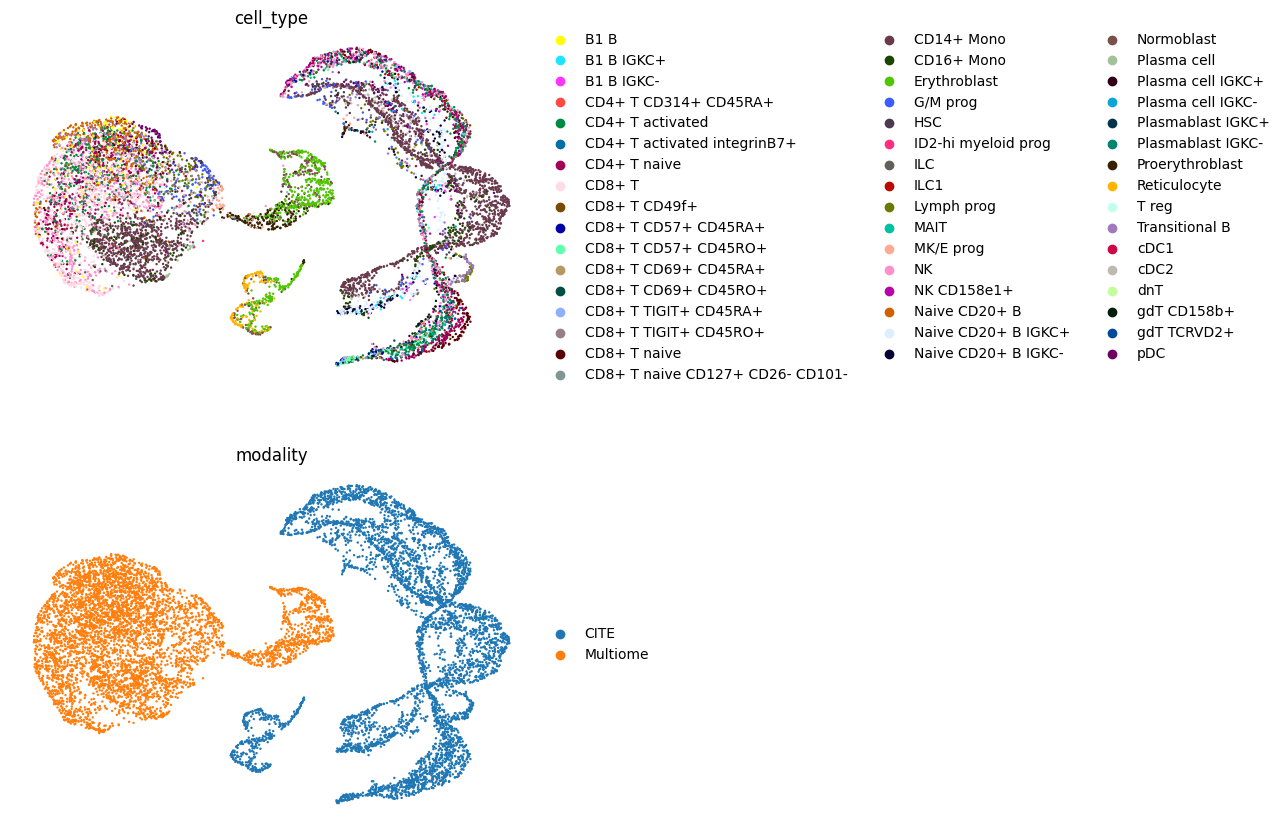

In [15]:
sc.pl.umap(adata, color=["cell_type", "modality"], frameon=False, ncols=1)